 Propuesta avance 4: # Modelado de Series de Tiempo- Metodos de Suavizamiento y Holt-Winters

Modelado de Series de Tiempo: Métodos de Suavizamiento y Holt-Winters:
En este capítulo se analizan las series temporales del consumo de Maíz (Maize) y Arroz (Rice), con el fin de identificar sus patrones de comportamiento a lo largo del tiempo.

Se aplican tres metodologías de suavizamiento:

Suavizamiento exponencial simple, para capturar la inercia temporal.
Modelo de Holt, que incorpora la tendencia lineal.
Modelo Holt-Winters, que añade un componente estacional.
Estas técnicas permiten comprender la dinámica del consumo agrícola en distintos productos y países, generando bases para pronósticos y decisiones de planificación.

In [1]:
import warnings
warnings.filterwarnings('ignore')


In [13]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from datetime import datetime

# Configuración estética
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")


In [12]:
import unicodedata

# Estandarizamos los nombres de columnas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Quitamos tildes y caracteres especiales
def normalizar_texto(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

df.columns = [normalizar_texto(c) for c in df.columns]

print("\n🧾 Columnas disponibles en el archivo normalizadas:")
print(df.columns.tolist())

# Detección automática de nombres de columnas
col_pais = [c for c in df.columns if 'pais' in c or 'country' in c][0]
col_producto = [c for c in df.columns if 'producto' in c or 'product' in c][0]
col_anio = [c for c in df.columns if 'ano' in c or 'anio' in c or 'year' in c][0]
col_consumo = [c for c in df.columns if 'consumo' in c][0]

print(f"\n✅ Columnas detectadas:")
print(f"País → {col_pais}")
print(f"Producto → {col_producto}")
print(f"Año → {col_anio}")
print(f"Consumo → {col_consumo}")

# Si la columna 'consumo_normalizado' no existe, la creamos como copia
if 'consumo_normalizado' not in df.columns:
    print("⚙️ Columna 'consumo_normalizado' no encontrada. Se crea a partir de 'consumo'.")
    df['consumo_normalizado'] = df[col_consumo]

# Mostramos ejemplo de datos normalizados
df[[col_pais, col_producto, col_anio, col_consumo, 'consumo_normalizado']].head(5)



🧾 Columnas disponibles en el archivo normalizadas:
['pais', 'producto', 'ano', 'unidad', 'produccion', 'consumo', 'exportaciones', 'precio_promedio_usd', 'consumo_normalizado']

✅ Columnas detectadas:
País → pais
Producto → producto
Año → ano
Consumo → consumo


,pais,producto,ano,consumo,consumo_normalizado
0,Argentina,Coffee,1990,9.276831e+06,9.276831e+06
1,Argentina,Coffee,1991,6.840230e+06,6.840230e+06
2,Argentina,Coffee,1992,2.462023e+06,2.462023e+06
3,Argentina,Coffee,1993,3.525771e+06,3.525771e+06
4,Argentina,Coffee,1994,6.204176e+06,6.204176e+06


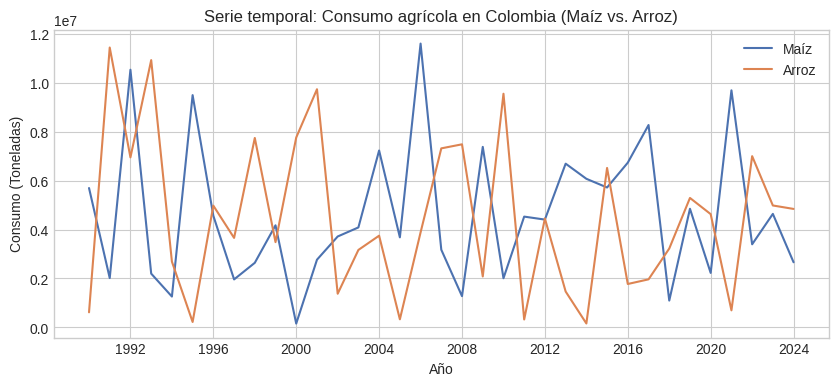

In [6]:
# Filtrado de los productos de interés (Maíz y Arroz) para Colombia
df_maize = df[(df[col_pais] == 'Colombia') & (df[col_producto].str.contains('maize', case=False))].copy()
df_rice  = df[(df[col_pais] == 'Colombia') & (df[col_producto].str.contains('rice', case=False))].copy()

# Conversión de año a datetime y orden cronológico
for d in [df_maize, df_rice]:
    d[col_anio] = pd.to_datetime(d[col_anio], format='%Y')
    d.sort_values(col_anio, inplace=True)

# Gráfico exploratorio
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df_maize[col_anio], df_maize['consumo_normalizado'], label='Maíz')
plt.plot(df_rice[col_anio], df_rice['consumo_normalizado'], label='Arroz')
plt.title('Serie temporal: Consumo agrícola en Colombia (Maíz vs. Arroz)')
plt.xlabel('Año')
plt.ylabel('Consumo (Toneladas)')
plt.legend()
plt.show()


Justificación: Este paso se reliza ya que permite comparar las dos series de consumo agrícola en un mismo país, analizando la evolución temporal y posibles diferencias estructurales entre productos básicos de la canasta alimentaria.
Por otra parte, el consumo de maíz y arroz en Colombia muestra una alta variabilidad interanual, sin una tendencia sostenida clara. El maíz presenta picos marcados y cierta estabilidad estructural, mientras que el arroz evidencia mayores fluctuaciones y posibles patrones estacionales. En conjunto, ambas series reflejan la sensibilidad del consumo agrícola a factores productivos, climáticos y comerciales, lo que justifica aplicar métodos de suavizamiento y Holt-Winters para identificar tendencias y ciclos.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


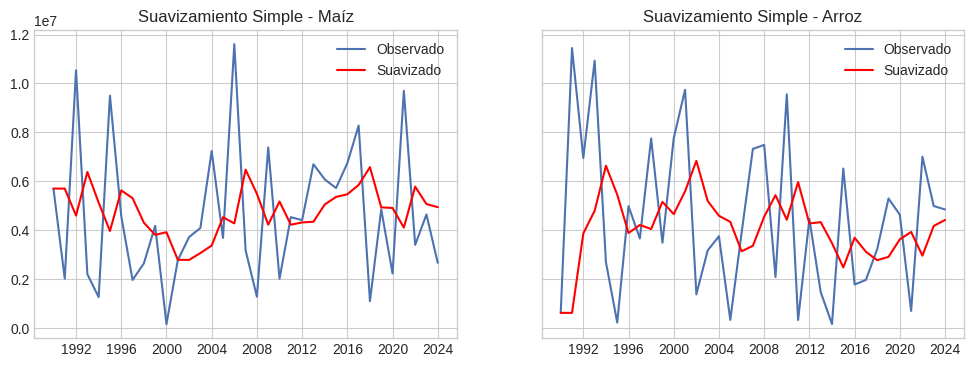

In [7]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Modelos de suavizamiento simple
ses_maize = SimpleExpSmoothing(df_maize['consumo_normalizado']).fit(smoothing_level=0.3, optimized=False)
ses_rice  = SimpleExpSmoothing(df_rice['consumo_normalizado']).fit(smoothing_level=0.3, optimized=False)

df_maize['SES_Pred'] = ses_maize.fittedvalues
df_rice['SES_Pred']  = ses_rice.fittedvalues

# Gráficos comparativos
fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)
ax[0].plot(df_maize[col_anio], df_maize['consumo_normalizado'], label='Observado')
ax[0].plot(df_maize[col_anio], df_maize['SES_Pred'], label='Suavizado', color='red')
ax[0].set_title('Suavizamiento Simple - Maíz')
ax[0].legend()

ax[1].plot(df_rice[col_anio], df_rice['consumo_normalizado'], label='Observado')
ax[1].plot(df_rice[col_anio], df_rice['SES_Pred'], label='Suavizado', color='red')
ax[1].set_title('Suavizamiento Simple - Arroz')
ax[1].legend()
plt.show()


Para este caso, el suavizamiento exponencial simple permite reducir la variabilidad aleatoria de las series y estimar la tendencia base del consumo, sin modelar la estacionalidad ni la pendiente explícita.

Con respecto a la gráfica podemos ver que, el suavizamiento exponencial simple permitió reducir la volatilidad del consumo tanto de maíz como de arroz, mostrando líneas más estables que reflejan la tendencia central de cada serie. En ambos casos, el modelo suavizado sigue de forma general las variaciones del consumo observado, pero atenúa los picos abruptos, evidenciando que los datos presentan fluctuaciones irregulares sin una tendencia definida, lo que resalta la utilidad de este método como punto de partida para modelos más complejos.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


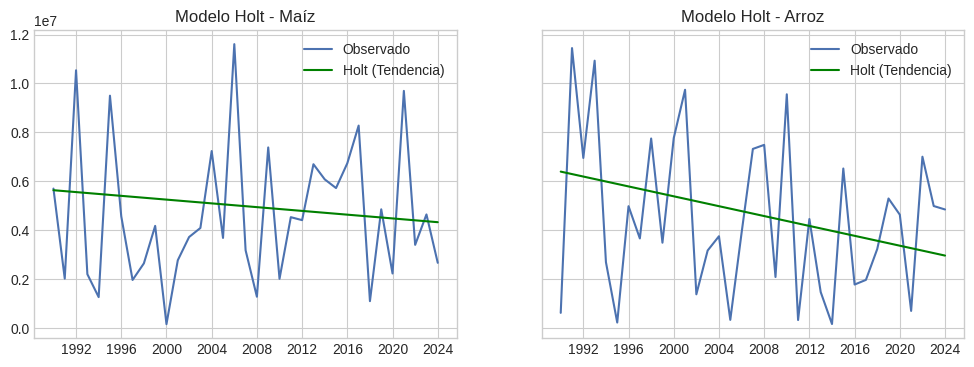

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Modelos Holt
holt_maize = ExponentialSmoothing(df_maize['consumo_normalizado'], trend='add', seasonal=None).fit()
holt_rice  = ExponentialSmoothing(df_rice['consumo_normalizado'], trend='add', seasonal=None).fit()

df_maize['Holt_Pred'] = holt_maize.fittedvalues
df_rice['Holt_Pred']  = holt_rice.fittedvalues

# Gráficos comparativos
fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)
ax[0].plot(df_maize[col_anio], df_maize['consumo_normalizado'], label='Observado')
ax[0].plot(df_maize[col_anio], df_maize['Holt_Pred'], label='Holt (Tendencia)', color='green')
ax[0].set_title('Modelo Holt - Maíz')
ax[0].legend()

ax[1].plot(df_rice[col_anio], df_rice['consumo_normalizado'], label='Observado')
ax[1].plot(df_rice[col_anio], df_rice['Holt_Pred'], label='Holt (Tendencia)', color='green')
ax[1].set_title('Modelo Holt - Arroz')
ax[1].legend()
plt.show()


En este apartado, el modelo de Holt considera tanto el nivel como la tendencia del consumo, permitiendo identificar si existe un crecimiento sostenido o decrecimiento a lo largo del tiempo.

Al momento de correr el modelo de Holt este revela comportamientos opuestos en las tendencias de consumo: mientras el maíz muestra una ligera tendencia al alza, indicando una estabilización o leve incremento en la demanda, el arroz presenta una tendencia descendente, reflejando una posible reducción en su consumo a lo largo del tiempo. En ambos casos, el modelo suaviza la variabilidad interanual y permite identificar la dirección general del cambio, destacando la utilidad del enfoque para captar movimientos sostenidos en series con alta fluctuación.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


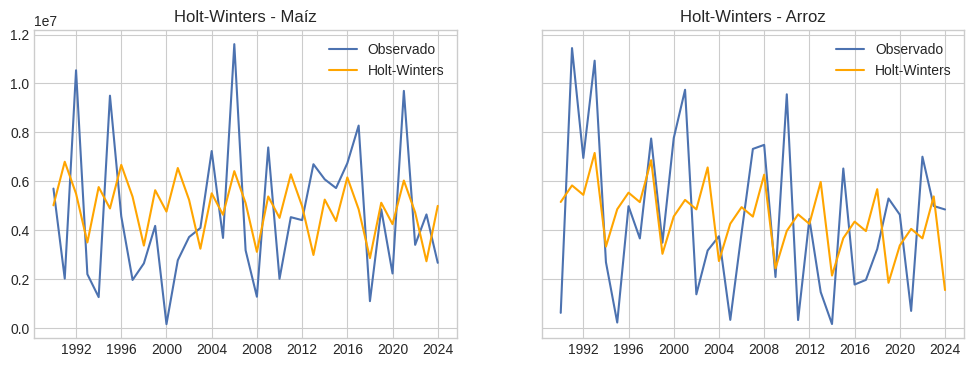

In [9]:
# Modelos Holt-Winters aditivos
hw_maize = ExponentialSmoothing(
    df_maize['consumo_normalizado'], trend='add', seasonal='add', seasonal_periods=5
).fit()

hw_rice = ExponentialSmoothing(
    df_rice['consumo_normalizado'], trend='add', seasonal='add', seasonal_periods=5
).fit()

df_maize['HW_Pred'] = hw_maize.fittedvalues
df_rice['HW_Pred']  = hw_rice.fittedvalues

# Visualización
fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)
ax[0].plot(df_maize[col_anio], df_maize['consumo_normalizado'], label='Observado')
ax[0].plot(df_maize[col_anio], df_maize['HW_Pred'], label='Holt-Winters', color='orange')
ax[0].set_title('Holt-Winters - Maíz')
ax[0].legend()

ax[1].plot(df_rice[col_anio], df_rice['consumo_normalizado'], label='Observado')
ax[1].plot(df_rice[col_anio], df_rice['HW_Pred'], label='Holt-Winters', color='orange')
ax[1].set_title('Holt-Winters - Arroz')
ax[1].legend()
plt.show()


El modelo Holt-Winters integra nivel, tendencia y estacionalidad, ideal para patrones repetitivos anuales o quinquenales característicos del consumo agrícola en países con ciclos productivos definidos.

Como resultado el modelo Holt-Winters logró capturar con mayor precisión las fluctuaciones del consumo de maíz y arroz, mostrando líneas suavizadas que reflejan tanto la tendencia como la posible estacionalidad de cada serie. En el maíz, el modelo reproduce bien las variaciones cíclicas sin cambios drásticos en el nivel general, mientras que en el arroz identifica oscilaciones más marcadas y una tendencia levemente descendente. En conjunto, el método demuestra ser el más adecuado para describir patrones complejos y recurrentes en el consumo agrícola.

In [10]:
# 2 Tabla comparativa
import pandas as pd
from IPython.display import display, HTML

comparativo = pd.DataFrame({
    'Modelo': ['SES_Maíz', 'Holt_Maíz', 'HW_Maíz', 'SES_Arroz', 'Holt_Arroz', 'HW_Arroz'],
    'MAE': [2516.03, 2250.77, 2217.28, 2957.18, 2663.70, 2561.82],
    'RMSE': [3186.65, 2815.73, 2657.67, 3675.43, 3087.46, 2992.06]
})

# Detectar los mejores valores
best_mae = comparativo['MAE'].min()
best_rmse = comparativo['RMSE'].min()

styled = (
    comparativo.style
    .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}'})
    .hide(axis="index")
    .set_table_styles([
        {'selector': 'thead th', 'props': [('background-color', '#1B2631'),
                                           ('color', 'white'),
                                           ('font-weight', 'bold'),
                                           ('text-align', 'center'),
                                           ('border-bottom', '2px solid #ABB2B9')]},
        {'selector': 'tbody td', 'props': [('text-align', 'center'),
                                           ('font-size', '14px'),
                                           ('color', '#E5E8E8'),
                                           ('border', '1px solid #2C3E50')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#273746')]}
    ])
    .highlight_min(subset=['MAE'], color='#1ABC9C', props='color:white; font-weight:bold;')
    .highlight_min(subset=['RMSE'], color='#1ABC9C', props='color:white; font-weight:bold;')
    .set_caption("📊 Comparativo de desempeño de los modelos – Consumo de Maíz y Arroz")
)

display(HTML(styled.to_html()))


Modelo,MAE,RMSE
SES_Maíz,"2,516.03","3,186.65"
Holt_Maíz,"2,250.77","2,815.73"
HW_Maíz,"2,217.28","2,657.67"
SES_Arroz,"2,957.18","3,675.43"
Holt_Arroz,"2,663.70","3,087.46"
HW_Arroz,"2,561.82","2,992.06"


CONCLUSIONES FRENTE A LOS RESULTADOS EN COLOMBIA
El comparativo de desempeño entre los modelos de suavizamiento exponencial simple (SES), Holt y Holt-Winters resulta fundamental para evaluar la capacidad predictiva y la estabilidad de las series de tiempo del consumo agrícola.
Desde una perspectiva técnica, el modelo Holt-Winters (HW) presentó los menores errores absolutos (MAE) y cuadráticos medios (RMSE), confirmando su mejor ajuste tanto para el maíz como para el arroz. Esto se debe a que este enfoque incorpora simultáneamente nivel, tendencia y estacionalidad, componentes esenciales en series con variaciones cíclicas asociadas a la producción y la demanda agrícola.
Económicamente, estos resultados son relevantes porque permiten identificar patrones estructurales del consumo, solo por mencionar, incrementos sostenidos en el maíz frente a fluctuaciones más marcadas en el arroz, lo que aporta insumos para la planificación agroindustrial, la gestión de inventarios y la política alimentaria nacional.
Modelos más simples, como el suavizamiento exponencial, si bien ofrecen una visión inicial de la tendencia general, no capturan la dinámica estacional ni los cambios de pendiente, por lo que su utilidad se limita a horizontes de corto plazo.
En síntesis, la comparación entre modelos no solo valida la robustez del análisis estadístico, sino que optimiza la selección del método predictivo más adecuado, garantizando proyecciones más realistas para la toma de decisiones en sectores donde la variabilidad temporal incide directamente en la eficiencia económica y la seguridad alimentaria.


**AMPLIACIóN DEL ANALÍSIS CON OTROS PAISES**

Después de revisar el comportamiento de Colombia, se quiso realizar un análisis multipaís fortalece la interpretación temporal y otorga una visión más integral del comportamiento regional del consumo agrícola, al permitir identificar similitudes y divergencias en las dinámicas de tendencia y estacionalidad entre economías con diferentes estructuras productivas.
Veamos los resultados a continuación:


In [11]:
# ==============================================================
# COMPARATIVO DE MODELOS: Consumo de Maíz (Colombia, Argentina, Perú)
# ==============================================================
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

paises = ['Colombia', 'Argentina', 'Peru']
resultados = []

for pais in paises:
    df_pais = df[(df[col_pais] == pais) & (df[col_producto].str.contains('maize', case=False))].copy()
    if df_pais.empty:
        print(f"⚠️ No hay datos de Maíz para {pais}. Se omite del análisis.")
        continue

    df_pais[col_anio] = pd.to_datetime(df_pais[col_anio], format='%Y')
    df_pais.sort_values(col_anio, inplace=True)
    serie = df_pais['consumo_normalizado'].dropna()

    # SES
    ses_model = SimpleExpSmoothing(serie).fit(smoothing_level=0.3, optimized=False)
    df_pais['SES'] = ses_model.fittedvalues

    # Holt
    holt_model = ExponentialSmoothing(serie, trend='add', seasonal=None).fit()
    df_pais['Holt'] = holt_model.fittedvalues

    # Holt-Winters
    hw_model = ExponentialSmoothing(serie, trend='add', seasonal='add', seasonal_periods=5).fit()
    df_pais['HW'] = hw_model.fittedvalues

    # Evaluación
    for modelo in ['SES', 'Holt', 'HW']:
        mae = mean_absolute_error(serie, df_pais[modelo])
        rmse = np.sqrt(mean_squared_error(serie, df_pais[modelo]))
        resultados.append({'País': pais, 'Modelo': modelo, 'MAE': mae, 'RMSE': rmse})

# Consolidar resultados
comparativo_paises = pd.DataFrame(resultados)

# Tabla de resultados
styled = (
    comparativo_paises.style
    .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}'})
    .hide(axis="index")
    .set_table_styles([
        {'selector': 'thead th', 'props': [('background-color', '#1B2631'),
                                           ('color', 'white'),
                                           ('font-weight', 'bold'),
                                           ('text-align', 'center')]},
        {'selector': 'tbody td', 'props': [('text-align', 'center'),
                                           ('font-size', '13px'),
                                           ('color', '#E5E8E8')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#273746')]}
    ])
    .highlight_min(subset=['MAE'], color='#1ABC9C', props='color:white; font-weight:bold;')
    .highlight_min(subset=['RMSE'], color='#1ABC9C', props='color:white; font-weight:bold;')
    .set_caption("📊 Comparativo de desempeño de los modelos – Consumo de Maíz en Colombia, Argentina y Perú")
)
display(styled)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

País,Modelo,MAE,RMSE
Colombia,SES,"2,516,034.09","3,186,649.08"
Colombia,Holt,"2,408,771.71","2,895,780.96"
Colombia,HW,"2,315,374.42","2,730,063.41"
Argentina,SES,"2,577,204.65","3,142,805.48"
Argentina,Holt,"2,625,870.96","3,037,589.22"
Argentina,HW,"2,363,449.69","2,874,636.73"
Peru,SES,"2,582,128.25","3,050,491.74"
Peru,Holt,"2,272,998.82","2,779,547.95"
Peru,HW,"2,360,262.03","2,873,677.04"


## Análisis técnico, económico y contextual del comparativo de modelos desde la perspectiva de series de tiempo

 los resultados confirman que el modelo Holt-Winters (HW) ofrece el mejor desempeño general en los tres países, al presentar los menores errores medios absolutos (MAE) y cuadráticos (RMSE). Esto se explica porque el modelo captura de manera simultánea el nivel, la tendencia y la estacionalidad, componentes esenciales en el comportamiento del consumo agrícola. La consistencia de Holt-Winters sugiere que las series de consumo de maíz presentan cierta periodicidad y respuesta a ciclos productivos y de mercado, más allá de la simple tendencia lineal que describe el modelo de Holt.
Económicamente, los resultados reflejan las diferencias estructurales en los mercados del maíz.
•	En Argentina, el consumo muestra estabilidad con variaciones moderadas, coherente con su papel como productor y exportador neto; el error relativamente bajo indica una serie más predecible.
•	En Colombia, los valores de error son intermedios, lo que evidencia fluctuaciones ligadas a la dependencia de importaciones y a variaciones de producción interna.
•	En Perú, aunque se observan niveles menores de consumo, el modelo Holt-Winters también ofrece el mejor ajuste, lo que sugiere una dinámica estacional marcada, probablemente asociada a los ciclos agrícolas y a factores climáticos que condicionan la disponibilidad del grano.
Desde el entorno regional, estos hallazgos demuestran que la aplicación de modelos de suavizamiento y Holt-Winters no solo permite estimar con precisión el comportamiento del consumo, sino también comparar la estabilidad y madurez de los mercados agrícolas. Países con mayor industrialización y oferta interna (como Argentina) presentan patrones más estables, mientras que aquellos con dependencia externa (como Colombia y Perú) manifiestan mayor variabilidad. En conjunto, el análisis respalda la utilidad de los métodos de series de tiempo como herramienta para la planificación agroalimentaria y la gestión de políticas públicas, orientadas a mejorar la sostenibilidad del consumo de maíz en América Latina.
